Phần 1: Thay đổi cấu trúc ANN
Tăng số nút ẩn: đổi lớp ẩn từ 4 nút thành 8 nút. Train 500 epoch. Ghi loss cuối, test accuracy.
Thêm một lớp ẩn: kiến trúc 2 → 8 (ReLU) → 6 (ReLU) → 1 (Sigmoid). Train 500 epoch.
So sánh 3 mô hình (4 nút / 8 nút / 8+6 nút) trên cùng đồ thị loss. Câu hỏi:
Mô hình to hơn có giảm loss nhanh hơn không? Có overfitting không?
Có hiện tượng diminishing returns (thêm nút không giúp thêm) không?

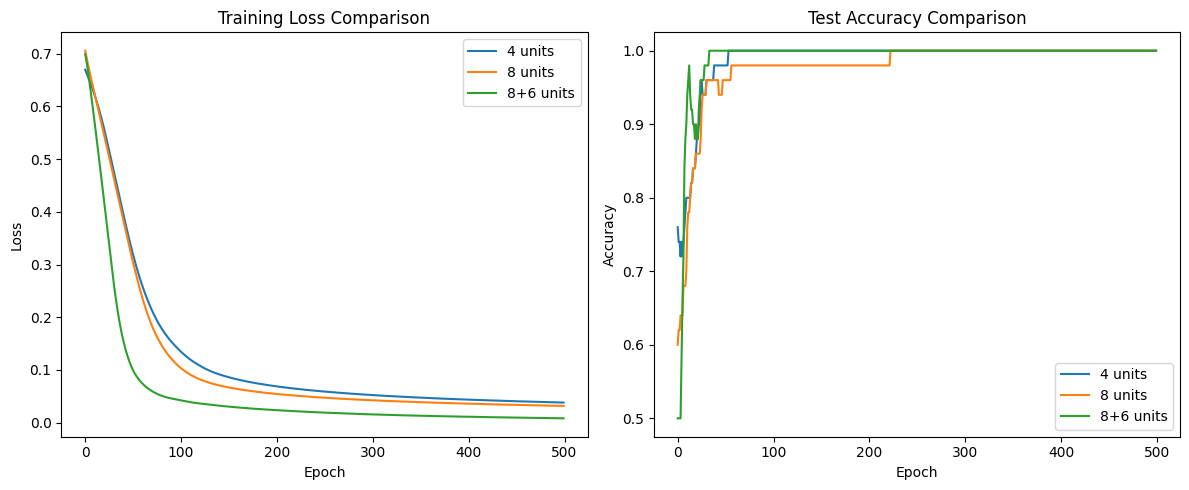

Final Loss (4/8/86): 0.0382 / 0.0318 / 0.0082
Final Accuracy (4/8/86): 1.0000 / 1.0000 / 1.0000


In [3]:
import torch
import torch.nn as nn
import torch.optim as optim
import matplotlib.pyplot as plt

# Tạo dữ liệu huấn luyện và kiểm tra
torch.manual_seed(42)
X_train = torch.randn(200, 2)
y_train = (torch.sigmoid(X_train[:, 0] * 2 - X_train[:, 1] * 0.5 + 0.1) > 0.5).float().unsqueeze(1)

X_test = torch.randn(50, 2)
y_test = (torch.sigmoid(X_test[:, 0] * 2 - X_test[:, 1] * 0.5 + 0.1) > 0.5).float().unsqueeze(1)

class ANN_4(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4), nn.ReLU(),
            nn.Linear(4, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class ANN_8(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8), nn.ReLU(),
            nn.Linear(8, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

class ANN_8_6(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 8), nn.ReLU(),
            nn.Linear(8, 6), nn.ReLU(),
            nn.Linear(6, 1), nn.Sigmoid()
        )
    def forward(self, x): return self.net(x)

def train(model, X_train, y_train, X_test, y_test, epochs=500, lr=0.01):
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCELoss()
    loss_history = []
    acc_history = []

    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        outputs = model(X_train)
        loss = criterion(outputs, y_train)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())

        # Tính Accuracy trên tập test
        model.eval()
        with torch.no_grad():
            preds = (model(X_test) > 0.5).float()
            acc = (preds == y_test).float().mean()
            acc_history.append(acc.item())

    return loss_history, acc_history

# Huấn luyện 3 mô hình
lh4, ah4 = train(ANN_4(), X_train, y_train, X_test, y_test)
lh8, ah8 = train(ANN_8(), X_train, y_train, X_test, y_test)
lh86, ah86 = train(ANN_8_6(), X_train, y_train, X_test, y_test)

# Vẽ đồ thị so sánh
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(lh4, label='4 units')
plt.plot(lh8, label='8 units')
plt.plot(lh86, label='8+6 units')
plt.title('Training Loss Comparison')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(ah4, label='4 units')
plt.plot(ah8, label='8 units')
plt.plot(ah86, label='8+6 units')
plt.title('Test Accuracy Comparison')
plt.xlabel('Epoch'); plt.ylabel('Accuracy'); plt.legend()

plt.tight_layout(); plt.show()

print(f"Final Loss (4/8/86): {lh4[-1]:.4f} / {lh8[-1]:.4f} / {lh86[-1]:.4f}")
print(f"Final Accuracy (4/8/86): {ah4[-1]:.4f} / {ah8[-1]:.4f} / {ah86[-1]:.4f}")

Phần 2: Loss và Optimizer
Đổi BCELoss thành BCEWithLogitsLoss: bỏ nn.Sigmoid khỏi model (BCEWithLogitsLoss tự xử lý). Train 500 epoch. Lưu ý: khi predict cần torch.sigmoid(output) > 0.5 chứ không phải output > 0.5.

Gợi ý: BCEWithLogitsLoss ổn định số học hơn vì gộp sigmoid + log thành một phép tính log(1 + exp(-x)) (log-sum-exp trick), tránh tràn số khi
 lớn.

Đổi Adam thành SGD (lr = 0.01, momentum = 0.9). Train 500 epoch. So sánh tốc độ hội tụ với Adam.

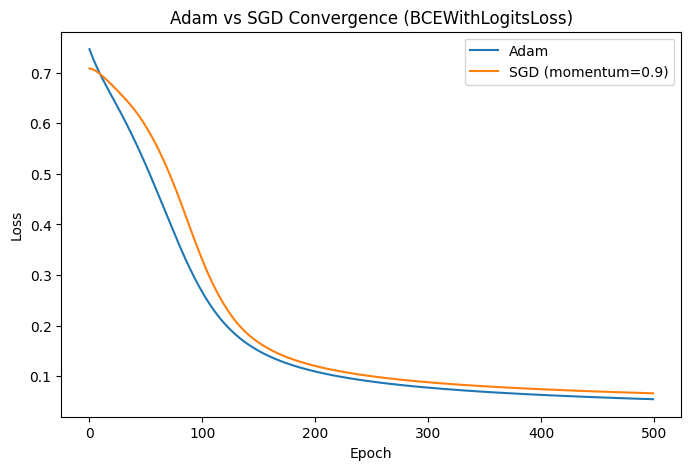

Final Loss - Adam: 0.0542
Final Loss - SGD: 0.0659


In [4]:
class ANN_Logits(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 4), nn.ReLU(),
            nn.Linear(4, 1)
        )
    def forward(self, x): return self.net(x)

def train_logits(model, optimizer_type='Adam'):
    if optimizer_type == 'Adam':
        optimizer = optim.Adam(model.parameters(), lr=0.01)
    else:
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)

    criterion = nn.BCEWithLogitsLoss()
    loss_history = []

    for epoch in range(500):
        model.train()
        optimizer.zero_grad()
        logits = model(X_train)
        loss = criterion(logits, y_train)
        loss.backward()
        optimizer.step()
        loss_history.append(loss.item())
    return loss_history

# So sánh Adam và SGD
loss_adam = train_logits(ANN_Logits(), 'Adam')
loss_sgd = train_logits(ANN_Logits(), 'SGD')

plt.figure(figsize=(8, 5))
plt.plot(loss_adam, label='Adam')
plt.plot(loss_sgd, label='SGD (momentum=0.9)')
plt.title('Adam vs SGD Convergence (BCEWithLogitsLoss)')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

print(f"Final Loss - Adam: {loss_adam[-1]:.4f}")
print(f"Final Loss - SGD: {loss_sgd[-1]:.4f}")

Phần 3: Phân tích sâu
Thử 3 learning rate: lr ∈ {0.001, 0.01, 0.1} với cấu trúc gốc. Vẽ 3 đường loss trên cùng đồ thị. Mô tả:

lr nào quá nhỏ → học chậm?
lr nào quá lớn → loss dao động hoặc nổ?
Vẽ ranh giới quyết định ở các epoch 10, 100, 500. Em nên thấy boundary từ thẳng dần dần thành cong tròn.

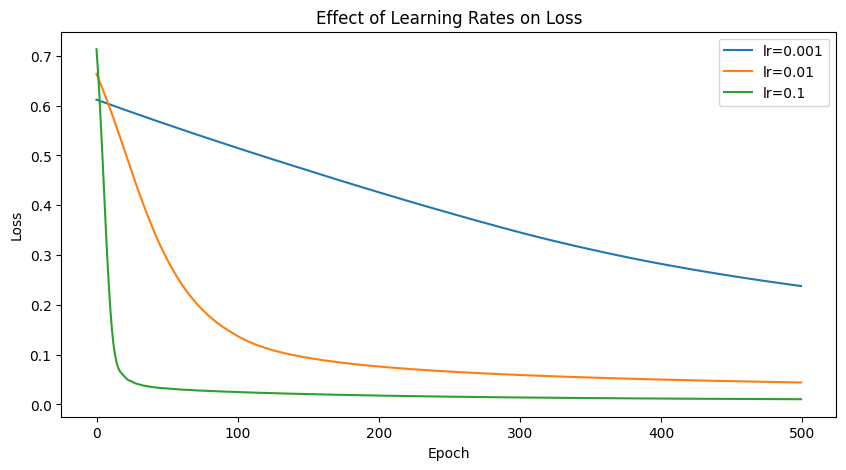

/tmp/ipykernel_1007/2436417574.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))


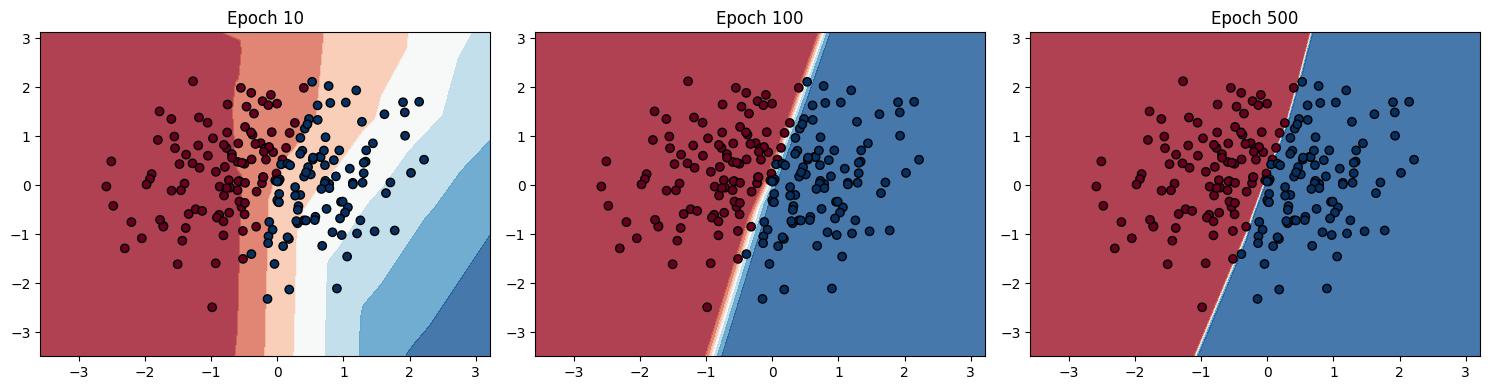

In [5]:
import numpy as np

def plot_decision_boundary(model, X, y, title):
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))
    grid = torch.from_numpy(np.c_[xx.ravel(), yy.ravel()]).float()

    model.eval()
    with torch.no_grad():
        # Kiểm tra xem model dùng Sigmoid hay Logits
        outputs = model(grid)
        if isinstance(model.net[-1], nn.Sigmoid):
            preds = outputs
        else:
            preds = torch.sigmoid(outputs)
        preds = preds.reshape(xx.shape).numpy()

    plt.contourf(xx, yy, preds, alpha=0.8, cmap='RdBu')
    plt.scatter(X[:, 0], X[:, 1], c=y.view(-1), edgecolors='k', cmap='RdBu')
    plt.title(title)

# 1. Thử nghiệm Learning Rates
lrs = [0.001, 0.01, 0.1]
plt.figure(figsize=(10, 5))
for lr in lrs:
    model = ANN_4()
    loss_h, _ = train(model, X_train, y_train, X_test, y_test, epochs=500, lr=lr)
    plt.plot(loss_h, label=f'lr={lr}')
plt.title('Effect of Learning Rates on Loss')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.show()

# 2. Vẽ Decision Boundary tại các mốc epoch
epochs_to_show = [10, 100, 500]
model = ANN_8_6() # Dùng model mạnh số 1
optimizer = optim.Adam(model.parameters(), lr=0.01)
criterion = nn.BCELoss()

plt.figure(figsize=(15, 4))
for i, epoch_limit in enumerate(epochs_to_show):
    current_epochs = epoch_limit if i == 0 else (epochs_to_show[i] - epochs_to_show[i-1])
    for _ in range(current_epochs):
        model.train()
        optimizer.zero_grad()
        loss = criterion(model(X_train), y_train)
        loss.backward()
        optimizer.step()

    plt.subplot(1, 3, i+1)
    plot_decision_boundary(model, X_train, y_train, f'Epoch {epoch_limit}')
plt.tight_layout(); plt.show()

Phần 4 (nâng cao, không bắt buộc)
Tự chế bộ dữ liệu khó hơn: 4 cụm xếp dạng XOR (góc trên trái + góc dưới phải = lớp 0, góc trên phải + góc dưới trái = lớp 1). Train ANN và xem boundary có học được dạng XOR không.

/tmp/ipykernel_1007/2436417574.py:6: DeprecationWarning: __array__ implementation doesn't accept a copy keyword, so passing copy=False failed. __array__ must implement 'dtype' and 'copy' keyword arguments.
  xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.01), np.arange(y_min, y_max, 0.01))


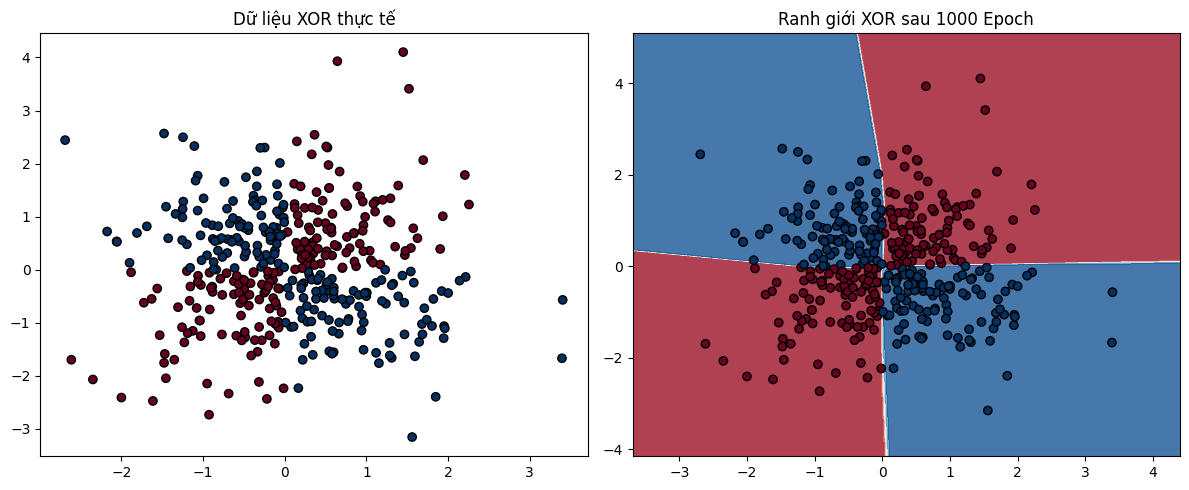

In [6]:
# 1. Tạo dữ liệu XOR
torch.manual_seed(0)
X_xor = torch.randn(400, 2)
y_xor = ((X_xor[:, 0] > 0) ^ (X_xor[:, 1] > 0)).float().unsqueeze(1)

# 2. Huấn luyện mô hình mạnh (8+6 nút) trên dữ liệu XOR
model_xor = ANN_8_6()
optimizer = optim.Adam(model_xor.parameters(), lr=0.01)
criterion = nn.BCELoss()

epochs = 1000
for epoch in range(epochs):
    model_xor.train()
    optimizer.zero_grad()
    loss = criterion(model_xor(X_xor), y_xor)
    loss.backward()
    optimizer.step()

# 3. Vẽ kết quả
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(X_xor[:, 0], X_xor[:, 1], c=y_xor.view(-1), cmap='RdBu', edgecolors='k')
plt.title("Dữ liệu XOR thực tế")

plt.subplot(1, 2, 2)
plot_decision_boundary(model_xor, X_xor, y_xor, f"Ranh giới XOR sau {epochs} Epoch")

plt.tight_layout()
plt.show()